In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [5]:
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print(f"Dataset Loaded: {df.shape[0]} customers analyzed.")

Dataset Loaded: 7032 customers analyzed.


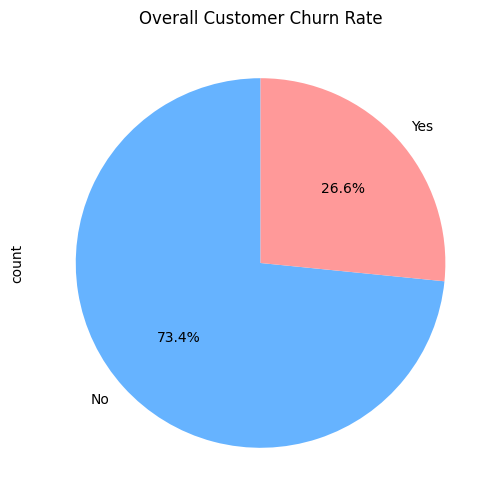

In [6]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Overall Customer Churn Rate')
plt.show()

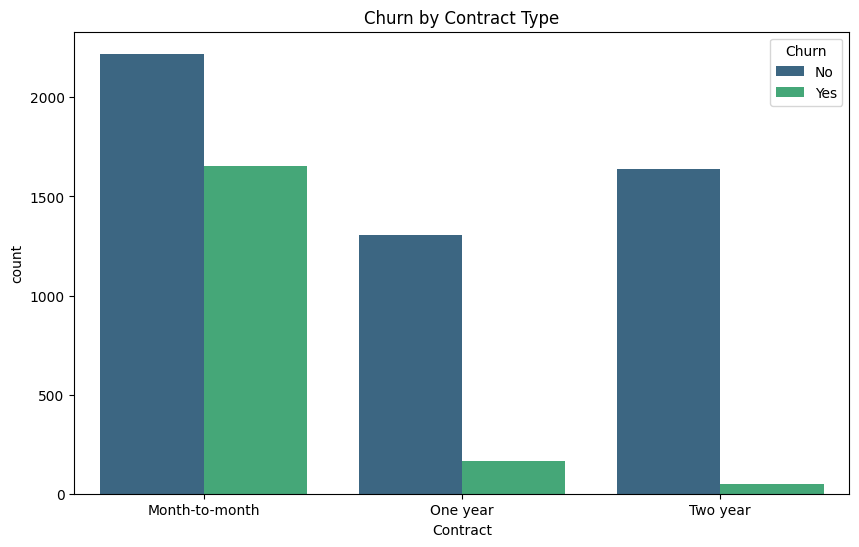

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn by Contract Type')
plt.show()

/tmp/ipykernel_1940/3600610239.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[(df['Churn']=='No'), 'tenure'], color='blue', shade=True, label='Stayed')
/tmp/ipykernel_1940/3600610239.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[(df['Churn']=='Yes'), 'tenure'], color='red', shade=True, label='Churned')


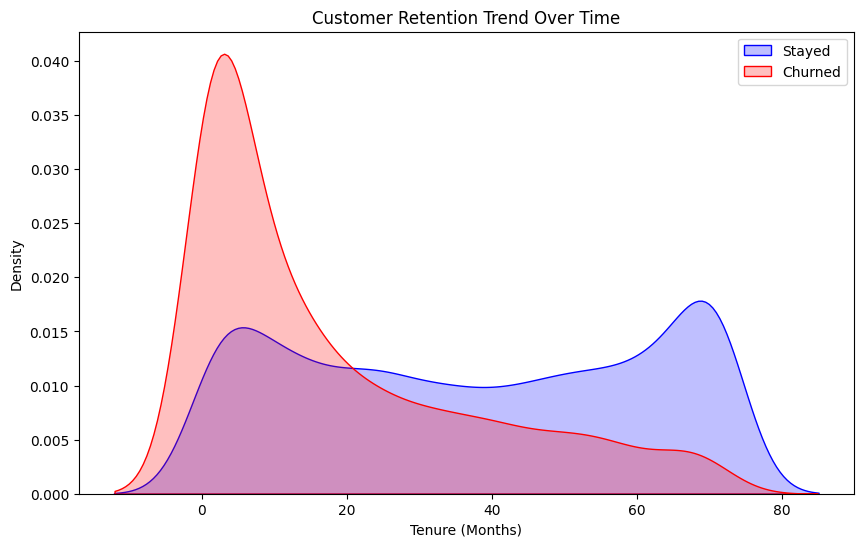

In [8]:
plt.figure(figsize=(10,6))
sns.kdeplot(df.loc[(df['Churn']=='No'), 'tenure'], color='blue', shade=True, label='Stayed')
sns.kdeplot(df.loc[(df['Churn']=='Yes'), 'tenure'], color='red', shade=True, label='Churned')
plt.xlabel('Tenure (Months)')
plt.title('Customer Retention Trend Over Time')
plt.legend()
plt.show()

In [9]:
correlation = df.select_dtypes(include=[np.number]).corr()['Churn_Numeric'].sort_values(ascending=False)
print("Top Churn Drivers (Numeric):\n", correlation)

Top Churn Drivers (Numeric):
 Churn_Numeric     1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_Numeric, dtype: float64
